In [16]:
# Cell 1 — Imports & sanity check
import datasets
import transformers
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(f"datasets:     {datasets.__version__}")
print(f"transformers: {transformers.__version__}")
print(f"torch:        {torch.__version__}")
print(f"pandas:       {pd.__version__}")
print(f"Device:       {'mps' if torch.backends.mps.is_available() else 'cpu'}")

datasets:     4.8.5
transformers: 5.9.0
torch:        2.12.0
pandas:       3.0.3
Device:       mps


In [17]:
# Cell 2 — Load dataset from Hugging Face Hub
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/sst2")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 872
    })
    test: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 1821
    })
})


In [18]:
# Cell 3 — First look at the data
import pandas as pd

# Convert the training split to a pandas DataFrame
train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()

# Look at the first 5 rows
print("Shape:", train_df.shape)
print("\nFirst 5 rows:")
train_df.head()

Shape: (67349, 3)

First 5 rows:


,idx,sentence,label
0,0,hide new secretions from the parental units,0
1,1,"contains no wit , only labored gags",0
2,2,that loves its characters and communicates som...,1
3,3,remains utterly satisfied to remain the same t...,0
4,4,on the worst revenge-of-the-nerds clichés the ...,0


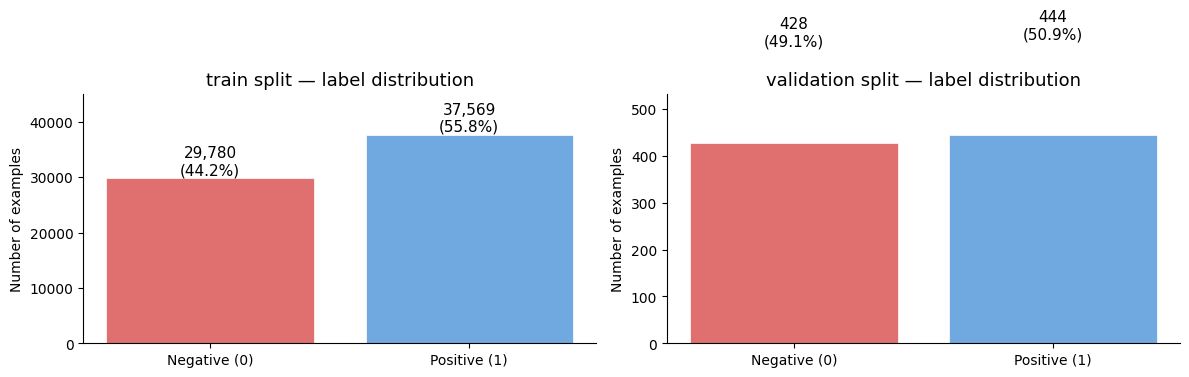


Train value counts:
label
1    37569
0    29780
Name: count, dtype: int64


In [19]:
# Cell 4 — Class distribution audit
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (split_name, df) in zip(axes, [("train", train_df), ("validation", val_df)]):
    counts = df["label"].value_counts().sort_index()
    bars = ax.bar(["Negative (0)", "Positive (1)"], counts.values, 
                  color=["#e07070", "#70a8e0"], edgecolor="white", linewidth=0.5)
    
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f"{count:,}\n({count/len(df)*100:.1f}%)",
                ha="center", va="bottom", fontsize=11)
    
    ax.set_title(f"{split_name} split — label distribution", fontsize=13)
    ax.set_ylabel("Number of examples")
    ax.set_ylim(0, counts.max() * 1.2)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nTrain value counts:")
print(train_df["label"].value_counts())

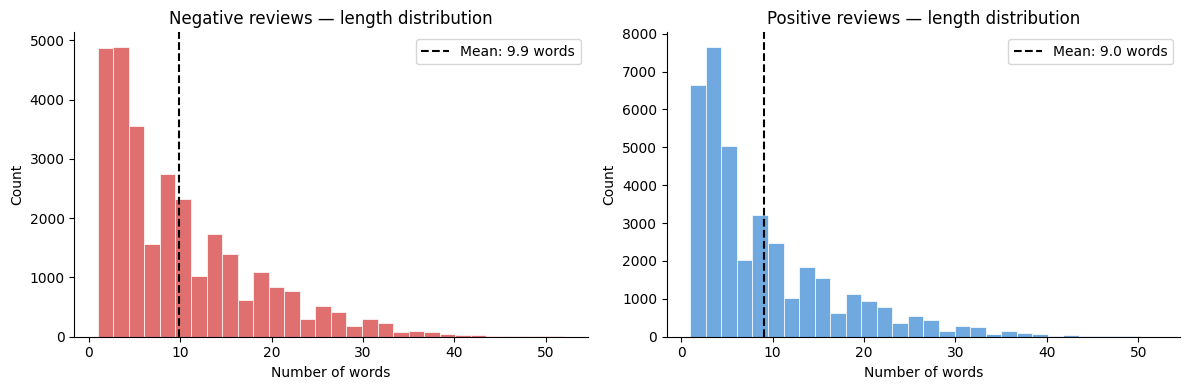

         count  mean   std  min  25%  50%   75%   max
label                                                
0      29780.0  9.88  8.16  1.0  3.0  8.0  14.0  52.0
1      37569.0  9.03  7.99  1.0  3.0  6.0  13.0  52.0


In [20]:
# Cell 5 — Review length audit
train_df["length"] = train_df["sentence"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, color, ax in zip([0, 1], ["#e07070", "#70a8e0"], axes):
    subset = train_df[train_df["label"] == label]["length"]
    ax.hist(subset, bins=30, color=color, edgecolor="white", linewidth=0.5)
    ax.axvline(subset.mean(), color="black", linestyle="--", linewidth=1.5,
               label=f"Mean: {subset.mean():.1f} words")
    ax.set_title(f"{'Negative' if label == 0 else 'Positive'} reviews — length distribution")
    ax.set_xlabel("Number of words")
    ax.set_ylabel("Count")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(train_df.groupby("label")["length"].describe().round(2))

In [21]:
# Cell 6 — Qualitative data inspection
print("=== NEGATIVE EXAMPLES (label=0) ===\n")
neg_samples = train_df[train_df["label"] == 0]["sentence"].sample(5, random_state=42)
for i, s in enumerate(neg_samples, 1):
    print(f"{i}. {s}")

print("\n=== POSITIVE EXAMPLES (label=1) ===\n")
pos_samples = train_df[train_df["label"] == 1]["sentence"].sample(5, random_state=42)
for i, s in enumerate(pos_samples, 1):
    print(f"{i}. {s}")

print("\n=== EDGE CASES — very short sentences (<=3 words) ===\n")
short = train_df[train_df["length"] <= 3][["sentence", "label"]].sample(8, random_state=42)
for _, row in short.iterrows():
    label_str = "POS" if row["label"] == 1 else "NEG"
    print(f"[{label_str}] '{row['sentence']}'")

=== NEGATIVE EXAMPLES (label=0) ===

1. a dull , dumb and derivative horror 
2. if george romero had directed this movie , it would n't have taken the protagonists a full hour to determine that in order to kill a zombie you must shoot it in the head 
3. the acting is amateurish , the cinematography is atrocious 
4. maudlin ending 
5. derailed 

=== POSITIVE EXAMPLES (label=1) ===

1. acted meditation on both the profoundly devastating events of one year ago and the slow , painful healing process that has followed in their wake 
2. this odd , poetic road movie , spiked by jolts of pop music , pretty much takes place in morton 's ever-watchful gaze -- and it 's a tribute to the actress , and to her inventive director , that the journey is such a mesmerizing one . 
3. directed with purpose and finesse by england 's roger mitchell , who handily makes the move from pleasing , relatively lightweight commercial fare such as notting hill to commercial fare with real thematic heft . 
4. long an

In [22]:
# Cell 7 — Load sentiment analysis pipeline
from transformers import pipeline
import torch

device = 0 if torch.backends.mps.is_available() else -1

print("Loading model...")
sentiment = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=device
)
print("Model loaded.")

# Test it on one sentence first
test_sentence = "This film was an absolute masterpiece"
result = sentiment(test_sentence)
print(f"\nTest: '{test_sentence}'")
print(f"Result: {result}")

Loading model...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 13351.93it/s]


Model loaded.

Test: 'This film was an absolute masterpiece'
Result: [{'label': 'POSITIVE', 'score': 0.999864935874939}]


In [23]:
# Cell 8 — Run inference on validation set
from tqdm.auto import tqdm

# Get sentences and true labels
sentences = val_df["sentence"].tolist()
true_labels = val_df["label"].tolist()

# Run in batches of 32 for speed
print("Running inference on validation set...")
predictions = sentiment(sentences, batch_size=32, truncation=True)

# Parse results back to 0/1
pred_labels = [1 if p["label"] == "POSITIVE" else 0 for p in predictions]
pred_scores = [p["score"] for p in predictions]

# Add to dataframe
val_df = val_df.copy()
val_df["pred_label"] = pred_labels
val_df["pred_score"] = pred_scores
val_df["correct"] = val_df["label"] == val_df["pred_label"]

print(f"Done. Evaluated {len(sentences)} examples.")
print(f"\nOverall accuracy: {val_df['correct'].mean():.4f}")

Running inference on validation set...
Done. Evaluated 872 examples.

Overall accuracy: 0.9106


In [24]:
# Cell 9 — Error analysis
errors = val_df[val_df["correct"] == False].copy()
correct = val_df[val_df["correct"] == True].copy()

print(f"Total errors: {len(errors)} / {len(val_df)} ({len(errors)/len(val_df)*100:.1f}%)")
print(f"\nError breakdown by true label:")
print(errors["label"].value_counts().rename({0: "True Negative (predicted POS)", 
                                              1: "True Positive (predicted NEG)"}))

# Add length column
errors["length"] = errors["sentence"].str.split().str.len()
correct["length"] = correct["sentence"].str.split().str.len()

print(f"\nMean length — errors:  {errors['length'].mean():.1f} words")
print(f"Mean length — correct: {correct['length'].mean():.1f} words")

print("\n=== ERRORS WHERE MODEL WAS MOST CONFIDENT (wrong but certain) ===\n")
confident_errors = errors.nlargest(8, "pred_score")
for _, row in confident_errors.iterrows():
    true_str = "POS" if row["label"] == 1 else "NEG"
    pred_str = "POS" if row["pred_label"] == 1 else "NEG"
    print(f"True: {true_str} | Predicted: {pred_str} | Confidence: {row['pred_score']:.3f}")
    print(f"  '{row['sentence']}'")
    print()

Total errors: 78 / 872 (8.9%)

Error breakdown by true label:
label
True Negative (predicted POS)    47
True Positive (predicted NEG)    31
Name: count, dtype: int64

Mean length — errors:  20.3 words
Mean length — correct: 19.5 words

=== ERRORS WHERE MODEL WAS MOST CONFIDENT (wrong but certain) ===

True: NEG | Predicted: POS | Confidence: 1.000
  'it 's somewhat clumsy and too lethargically paced -- but its story about a mysterious creature with psychic abilities offers a solid build-up , a terrific climax , and some nice chills along the way . '

True: NEG | Predicted: POS | Confidence: 1.000
  'although huppert 's intensity and focus has a raw exhilaration about it , the piano teacher is anything but fun . '

True: NEG | Predicted: POS | Confidence: 1.000
  'the lower your expectations , the more you 'll enjoy it . '

True: NEG | Predicted: POS | Confidence: 1.000
  'the longer the movie goes , the worse it gets , but it 's actually pretty good in the first few minutes . '

True: 

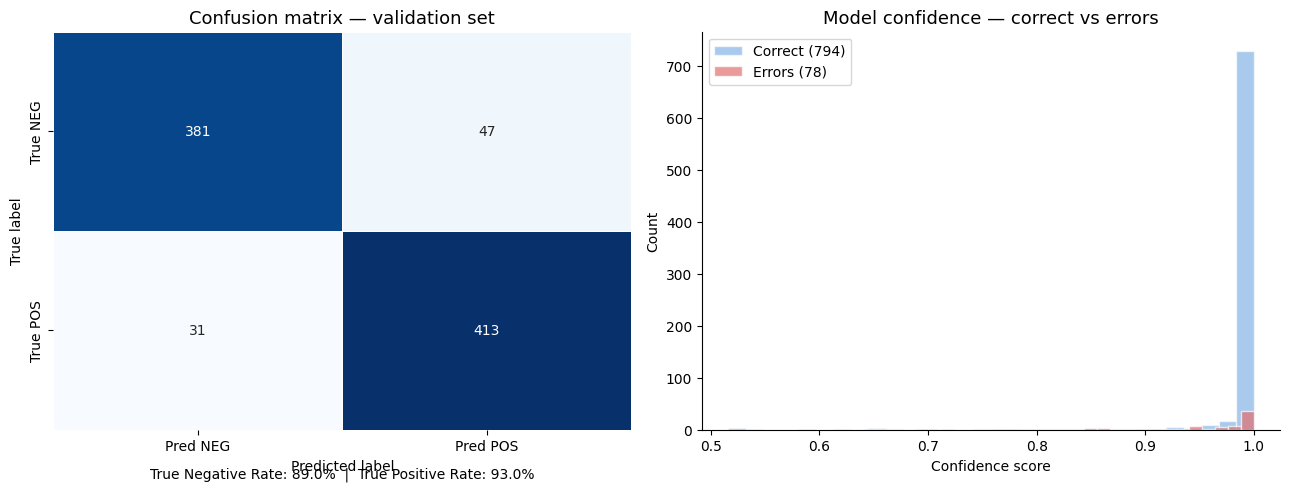

In [25]:
# Cell 10 — Confusion matrix + confidence distribution
from sklearn.metrics import confusion_matrix
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion matrix ---
cm = confusion_matrix(val_df["label"], val_df["pred_label"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Pred NEG", "Pred POS"],
            yticklabels=["True NEG", "True POS"],
            linewidths=0.5, cbar=False)
axes[0].set_title("Confusion matrix — validation set", fontsize=13)
axes[0].set_ylabel("True label")
axes[0].set_xlabel("Predicted label")

# Annotate with rates
total_neg = cm[0].sum()
total_pos = cm[1].sum()
axes[0].text(0.5, -0.12,
    f"True Negative Rate: {cm[0,0]/total_neg:.1%}  |  "
    f"True Positive Rate: {cm[1,1]/total_pos:.1%}",
    transform=axes[0].transAxes, ha="center", fontsize=10)

# --- Confidence distribution: correct vs errors ---
axes[1].hist(correct["pred_score"], bins=30, alpha=0.6, 
             color="#70a8e0", label=f"Correct ({len(correct)})", edgecolor="white")
axes[1].hist(errors["pred_score"], bins=30, alpha=0.7,
             color="#e07070", label=f"Errors ({len(errors)})", edgecolor="white")
axes[1].set_title("Model confidence — correct vs errors", fontsize=13)
axes[1].set_xlabel("Confidence score")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("confusion_confidence.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


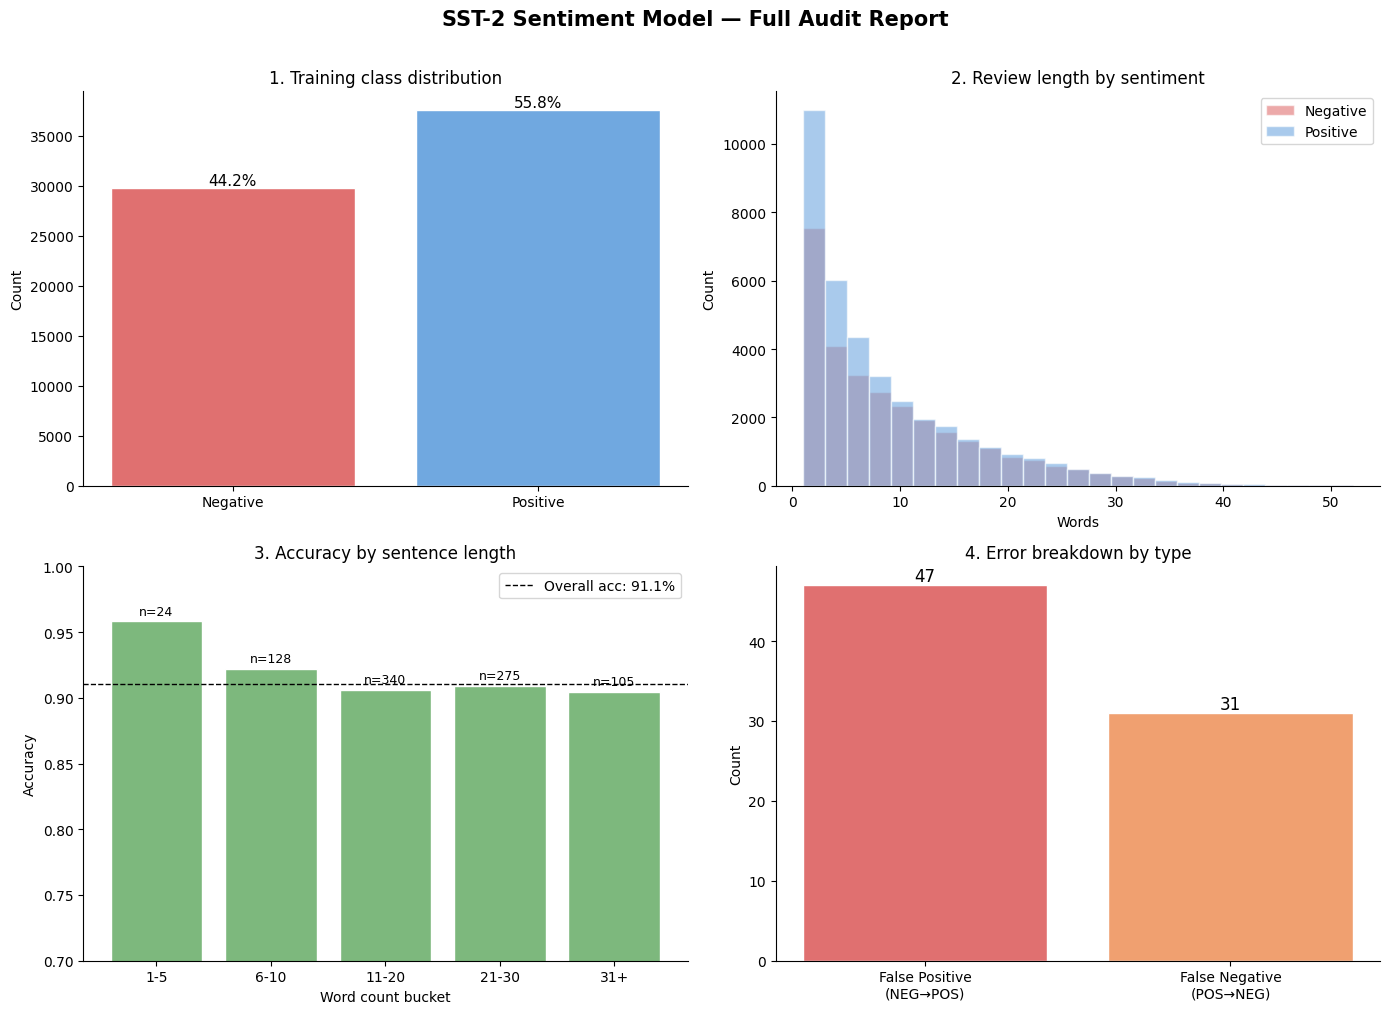

Audit report saved.


In [27]:
# Cell 11 — Final audit summary
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("SST-2 Sentiment Model — Full Audit Report", fontsize=15, fontweight="bold", y=1.01)

# --- 1. Class distribution ---
ax = axes[0, 0]
counts = train_df["label"].value_counts().sort_index()
bars = ax.bar(["Negative", "Positive"], counts.values,
              color=["#e07070", "#70a8e0"], edgecolor="white")
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f"{count/len(train_df)*100:.1f}%", ha="center", fontsize=11)
ax.set_title("1. Training class distribution", fontsize=12)
ax.set_ylabel("Count")
ax.spines[["top", "right"]].set_visible(False)

# --- 2. Length by label --- (fixed)
ax = axes[0, 1]
for label, color, name in zip([0, 1], ["#e07070", "#70a8e0"], ["Negative", "Positive"]):
    subset = train_df[train_df["label"] == label]["length"]
    ax.hist(subset, bins=25, alpha=0.6, color=color, label=name, edgecolor="white")
ax.set_title("2. Review length by sentiment", fontsize=12)
ax.set_xlabel("Words")
ax.set_ylabel("Count")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

# --- 3. Accuracy by length bucket ---
ax = axes[1, 0]
val_df["length"] = val_df["sentence"].str.split().str.len()
val_df["length_bucket"] = pd.cut(val_df["length"], 
                                  bins=[0, 5, 10, 20, 30, 100],
                                  labels=["1-5", "6-10", "11-20", "21-30", "31+"])
acc_by_length = val_df.groupby("length_bucket", observed=True)["correct"].agg(["mean", "count"])
bars = ax.bar(acc_by_length.index, acc_by_length["mean"],
              color="#7db87d", edgecolor="white")
for bar, (_, row) in zip(bars, acc_by_length.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"n={int(row['count'])}", ha="center", fontsize=9)
ax.axhline(0.9106, color="black", linestyle="--", linewidth=1, label="Overall acc: 91.1%")
ax.set_title("3. Accuracy by sentence length", fontsize=12)
ax.set_xlabel("Word count bucket")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.7, 1.0)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

# --- 4. Error types ---
ax = axes[1, 1]
error_types = ["False Positive\n(NEG→POS)", "False Negative\n(POS→NEG)"]
error_counts = [47, 31]
bars = ax.bar(error_types, error_counts, color=["#e07070", "#f0a070"], edgecolor="white")
for bar, count in zip(bars, error_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(count), ha="center", fontsize=12)
ax.set_title("4. Error breakdown by type", fontsize=12)
ax.set_ylabel("Count")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("audit_report.png", dpi=150, bbox_inches="tight")
plt.show()
print("Audit report saved.")